In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "../data/processed/cleaned_fraud_data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (6362620, 9)


In [3]:
fraud_counts = df["isFraud"].value_counts()

print("Legitimate transactions:", fraud_counts[0])
print("Fraudulent transactions:", fraud_counts[1])

Legitimate transactions: 6354407
Fraudulent transactions: 8213


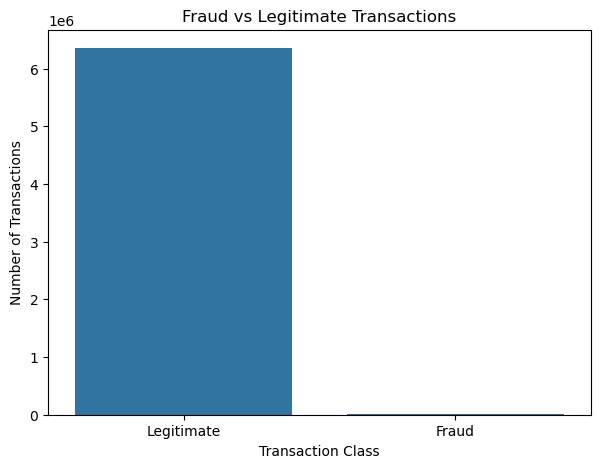

In [4]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.show()

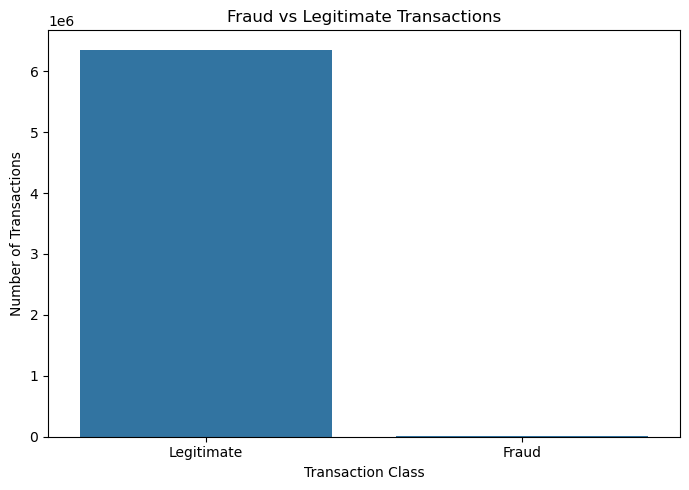

In [5]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.tight_layout()

plt.savefig(
    "../images/fraud_vs_legitimate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

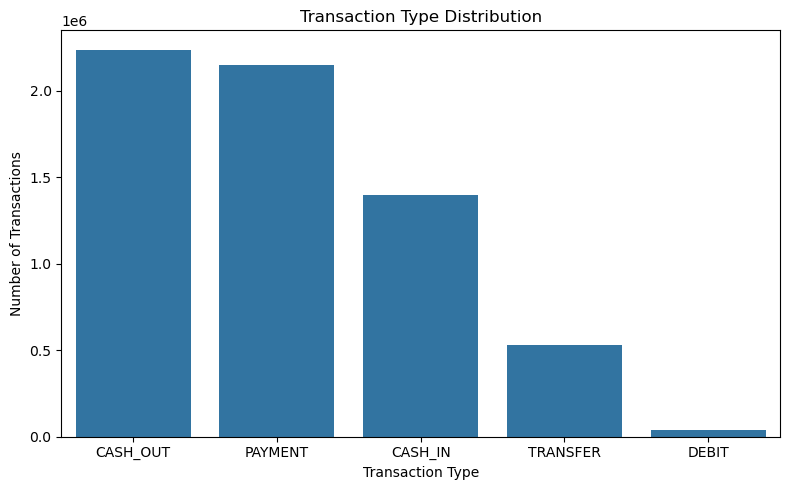

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    order=df["type"].value_counts().index
)

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [7]:
fraud_by_type = pd.crosstab(
    df["type"],
    df["isFraud"]
)

print(fraud_by_type)

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


In [8]:
fraud_rate_by_type = (
    df.groupby("type")["isFraud"]
    .mean()
    .sort_values(ascending=False)
)

print(fraud_rate_by_type)

type
TRANSFER    0.007688
CASH_OUT    0.001840
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


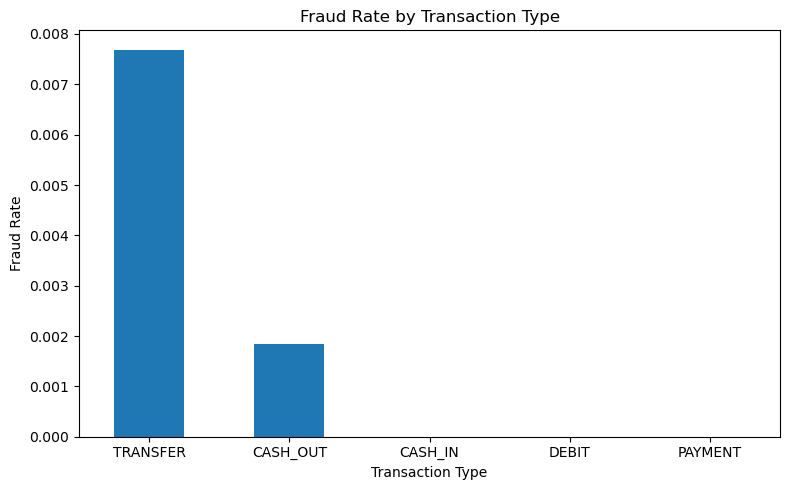

In [9]:
plt.figure(figsize=(8, 5))

fraud_rate_by_type.plot(
    kind="bar"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

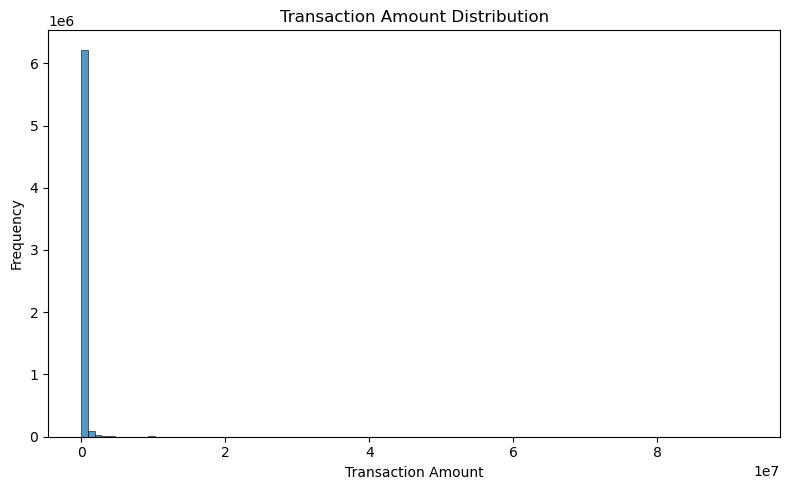

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="amount",
    bins=100
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

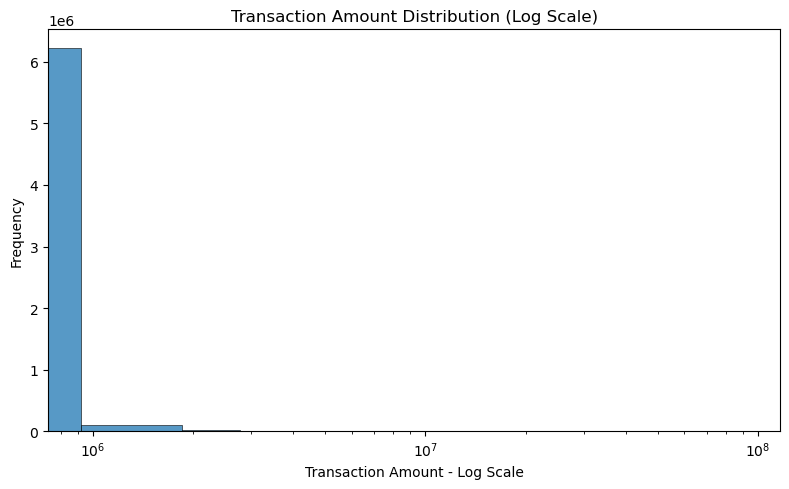

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="amount",
    bins=100
)

plt.xscale("log")

plt.title("Transaction Amount Distribution (Log Scale)")
plt.xlabel("Transaction Amount - Log Scale")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
fraud_df = df[df["isFraud"] == 1]

print("Fraud transactions:", len(fraud_df))
print(fraud_df["amount"].describe())

Fraud transactions: 8213
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64


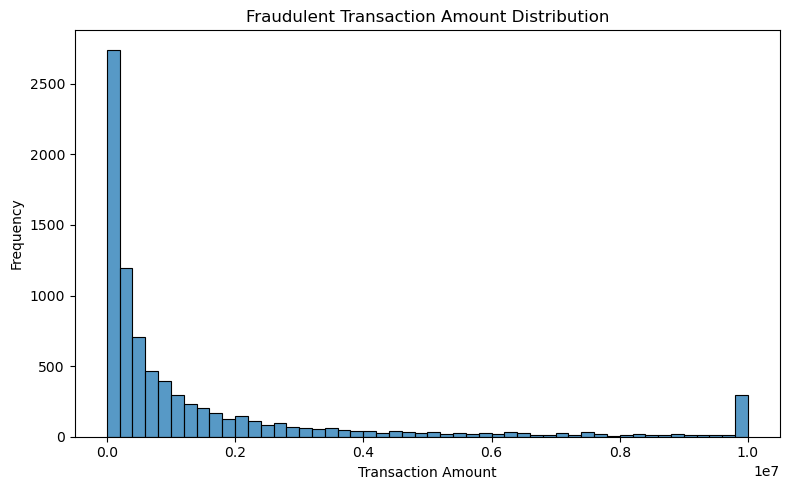

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=fraud_df,
    x="amount",
    bins=50
)

plt.title("Fraudulent Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
numerical_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

fraud_comparison = df.groupby("isFraud")[numerical_features].mean()

print(fraud_comparison)

               amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
isFraud                                                                
0        1.781970e+05   8.328287e+05   855970.228109    1.101421e+06   
1        1.467967e+06   1.649668e+06   192392.631836    5.442496e+05   

         newbalanceDest  
isFraud                  
0          1.224926e+06  
1          1.279708e+06  


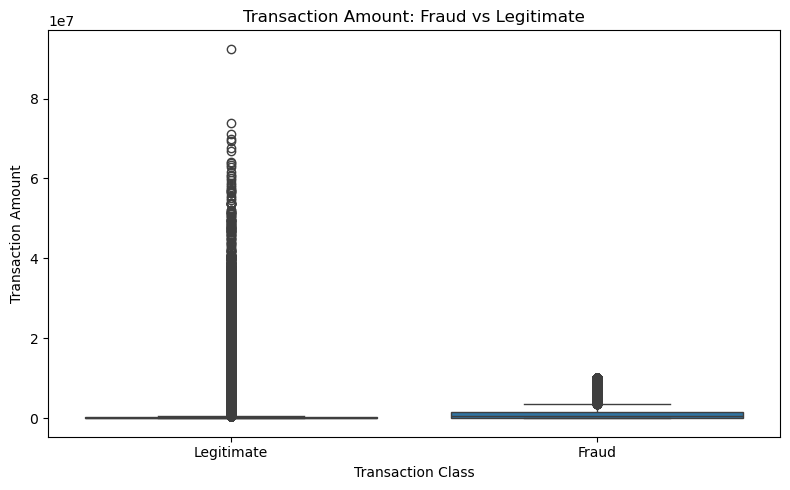

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.title("Transaction Amount: Fraud vs Legitimate")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.xticks(
    [0, 1],
    ["Legitimate", "Fraud"]
)

plt.tight_layout()
plt.show()

In [16]:
numerical_df = df.select_dtypes(include=np.number)

correlation_matrix = numerical_df.corr()

print(correlation_matrix)

                    step    amount  oldbalanceOrg  newbalanceOrig  \
step            1.000000  0.022373      -0.010058       -0.010299   
amount          0.022373  1.000000      -0.002762       -0.007861   
oldbalanceOrg  -0.010058 -0.002762       1.000000        0.998803   
newbalanceOrig -0.010299 -0.007861       0.998803        1.000000   
oldbalanceDest  0.027665  0.294137       0.066243        0.067812   
newbalanceDest  0.025888  0.459304       0.042029        0.041837   
isFraud         0.031578  0.076688       0.010154       -0.008148   
isFlaggedFraud  0.003277  0.012295       0.003835        0.003776   

                oldbalanceDest  newbalanceDest   isFraud  isFlaggedFraud  
step                  0.027665        0.025888  0.031578        0.003277  
amount                0.294137        0.459304  0.076688        0.012295  
oldbalanceOrg         0.066243        0.042029  0.010154        0.003835  
newbalanceOrig        0.067812        0.041837 -0.008148        0.003776  
old

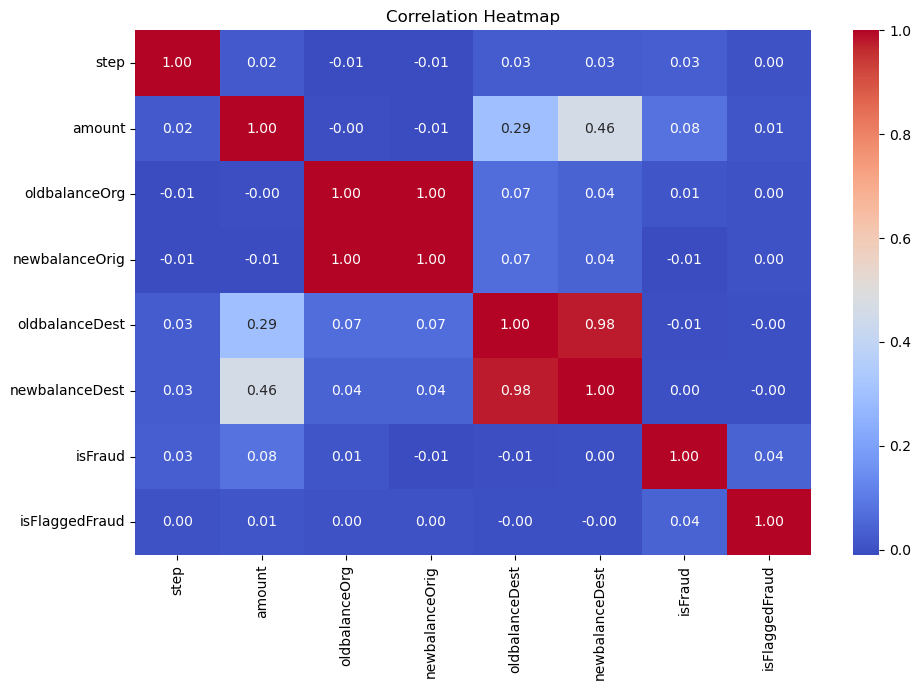

In [17]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

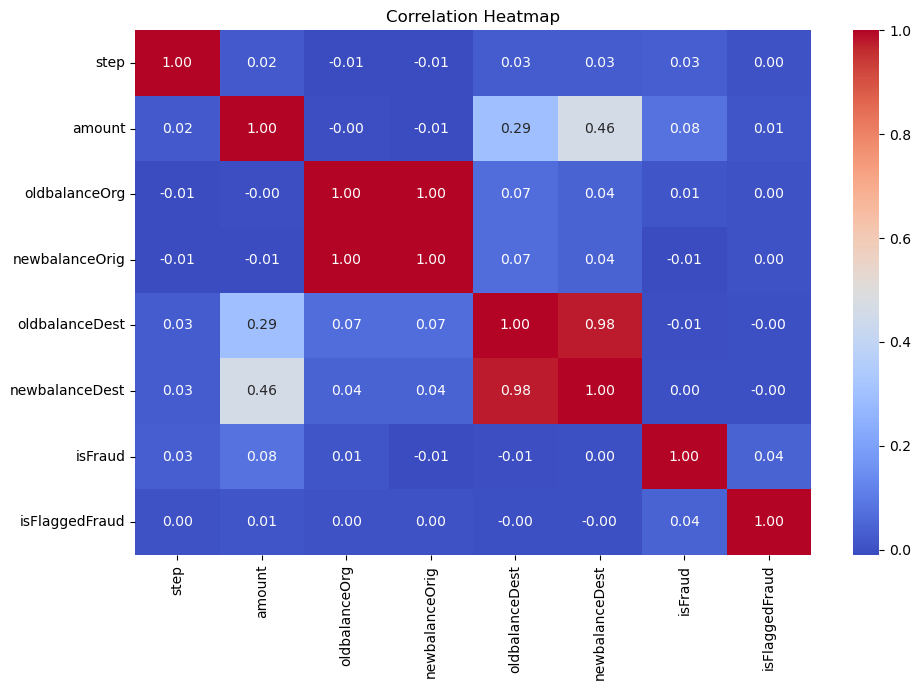

In [18]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
fraud_rate_percentage = (
    df.groupby("type")["isFraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(fraud_rate_percentage)

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


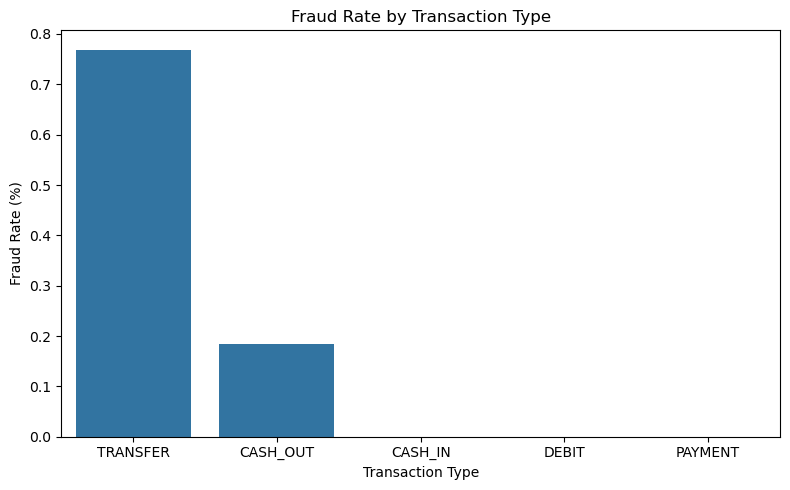

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_rate_percentage.index,
    y=fraud_rate_percentage.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

In [21]:
print(fraud_rate_percentage)

type
TRANSFER    0.768799
CASH_OUT    0.183955
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [22]:
print(fraud_comparison)

               amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
isFraud                                                                
0        1.781970e+05   8.328287e+05   855970.228109    1.101421e+06   
1        1.467967e+06   1.649668e+06   192392.631836    5.442496e+05   

         newbalanceDest  
isFraud                  
0          1.224926e+06  
1          1.279708e+06  


In [24]:
fraud_df["amount"].describe()

count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

In [23]:
print(correlation_matrix)

                    step    amount  oldbalanceOrg  newbalanceOrig  \
step            1.000000  0.022373      -0.010058       -0.010299   
amount          0.022373  1.000000      -0.002762       -0.007861   
oldbalanceOrg  -0.010058 -0.002762       1.000000        0.998803   
newbalanceOrig -0.010299 -0.007861       0.998803        1.000000   
oldbalanceDest  0.027665  0.294137       0.066243        0.067812   
newbalanceDest  0.025888  0.459304       0.042029        0.041837   
isFraud         0.031578  0.076688       0.010154       -0.008148   
isFlaggedFraud  0.003277  0.012295       0.003835        0.003776   

                oldbalanceDest  newbalanceDest   isFraud  isFlaggedFraud  
step                  0.027665        0.025888  0.031578        0.003277  
amount                0.294137        0.459304  0.076688        0.012295  
oldbalanceOrg         0.066243        0.042029  0.010154        0.003835  
newbalanceOrig        0.067812        0.041837 -0.008148        0.003776  
old

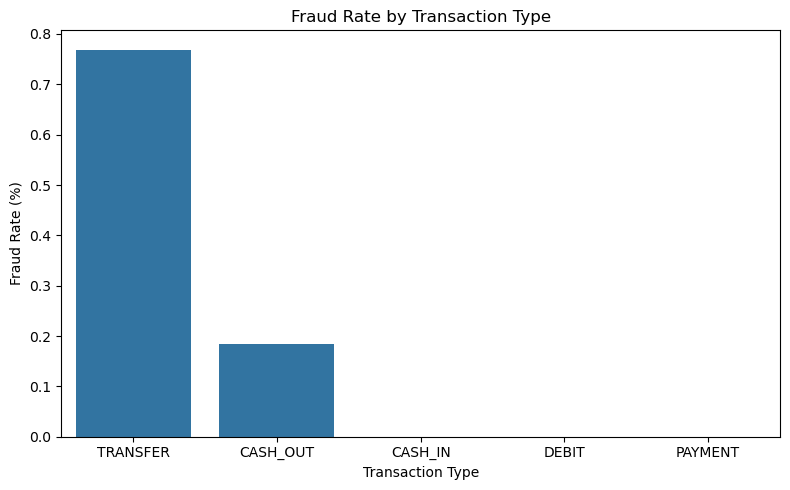

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=fraud_rate_percentage.index,
    y=fraud_rate_percentage.values
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()

plt.savefig(
    "../images/fraud_rate_by_transaction_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## EDA Findings

1. Fraudulent transactions represent only about 0.13% of the dataset,
   confirming severe class imbalance.

2. In this dataset, fraudulent transactions occur in the TRANSFER and
   CASH_OUT transaction types, while CASH_IN, DEBIT, and PAYMENT contain
   no fraudulent transactions.

3. Fraudulent transactions have a substantially higher average transaction
   amount than legitimate transactions.

4. Fraud transaction amounts are strongly right-skewed, with the median
   substantially lower than the mean.

5. The transaction amount has the strongest numerical correlation with
   the fraud target, although the correlation is still relatively weak.

6. The sender balance-before and balance-after features are highly
   correlated, as are the receiver balance-before and balance-after
   features.

7. The extreme imbalance between legitimate and fraudulent transactions
   means that accuracy alone will not be an appropriate measure of model
   performance.